# Multivariate Pattern Analysis 
Objective:
To uncover complex relationships between multiple features and their combined effect on churn.

Focus:
- Correlation analysis
- Partial correlations
- Feature interactions
- Risk surfaces

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("../dataset/processed/credit_card_clean.csv")

In [3]:
df["Attrition_Flag"] = df["Attrition_Flag"].str.strip()

df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

df = df.dropna(subset=["Attrition_Flag"])
df["Attrition_Flag"] = df["Attrition_Flag"].astype(int)

In [7]:
df["Transaction_Velocity"] = df["Total_Trans_Ct"] / 12
print(df["Transaction_Velocity"].head())

0    3.500000
1    2.750000
2    1.666667
3    1.666667
4    2.333333
Name: Transaction_Velocity, dtype: float64


In [8]:
df["Engagement"] = df["Total_Trans_Ct"] / df["Months_on_book"]
print(df["Engagement"].head())

0    1.076923
1    0.750000
2    0.555556
3    0.588235
4    1.333333
Name: Engagement, dtype: float64


In [9]:
df["Utilization"] = df["Avg_Utilization_Ratio"]
print(df["Utilization"].head())

0    0.061
1    0.105
2    0.000
3    0.760
4    0.000
Name: Utilization, dtype: float64


In [5]:
df["Engagement"] = df["Engagement"].replace([np.inf, -np.inf], np.nan)

df = df.dropna(subset=[
    "Transaction_Velocity",
    "Engagement",
    "Utilization",
    "Attrition_Flag"
])

# CORRELATION ANALYSIS

In [10]:
num_df = df.select_dtypes(include=np.number)

**Pearson Heatmap**

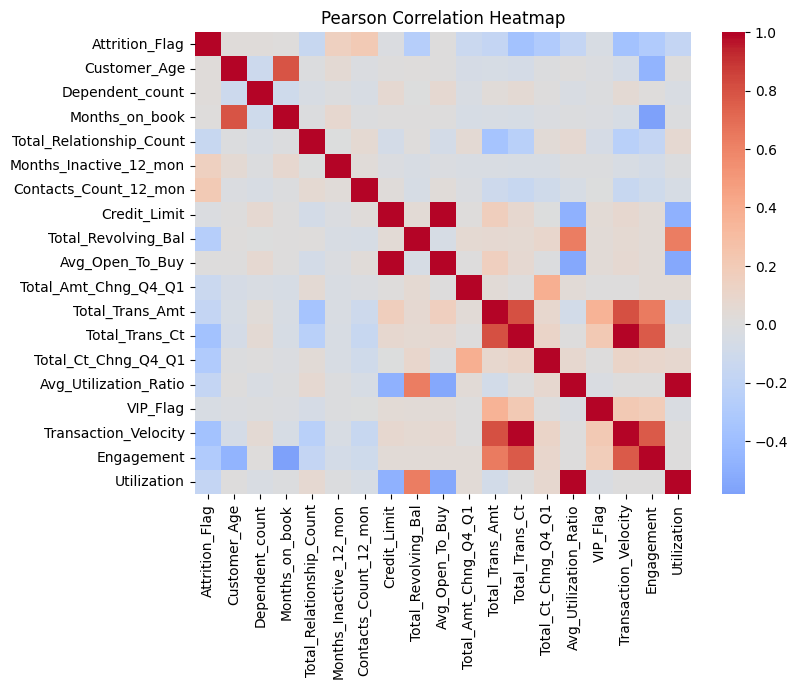

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Pearson Correlation Heatmap")
plt.show()

**Spaerman Heatmap**

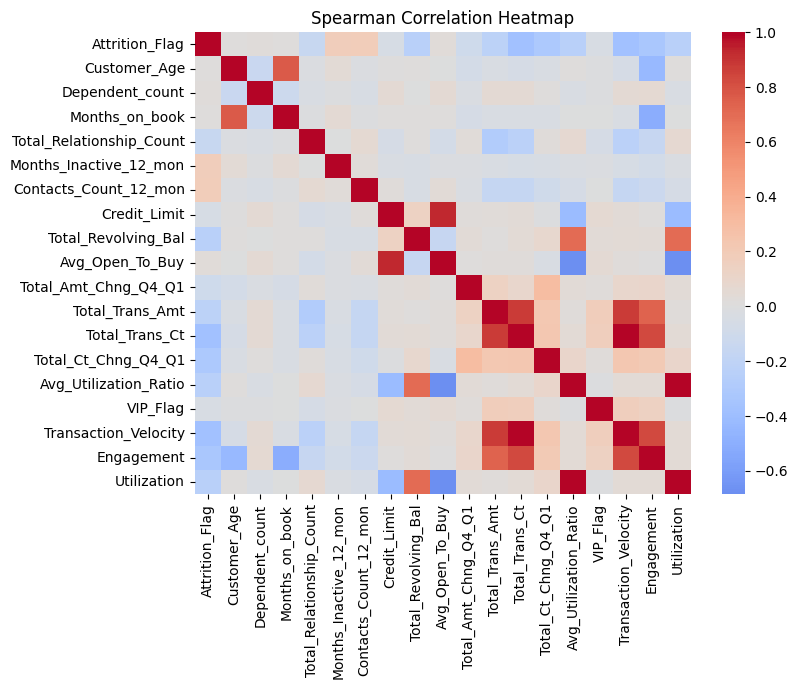

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(method="spearman"), cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap")
plt.show()

Spearman correlation reveals monotonic relationships which are common in financial behavior.

# PARTIAL CORRELATION

In [14]:
def partial_corr(x, y, z):
    model_x = LinearRegression().fit(z, x)
    model_y = LinearRegression().fit(z, y)

    res_x = x - model_x.predict(z)
    res_y = y - model_y.predict(z)

    return np.corrcoef(res_x, res_y)[0,1]

In [15]:
features = [
    "Transaction_Velocity",
    "Engagement",
    "Utilization",
    "Credit_Limit",
    "Total_Trans_Amt",
    "Total_Trans_Ct"
]

results = []

for col in features:
    x = df[col]
    y = df["Attrition_Flag"]
    z = df[[f for f in features if f != col]]

    pcorr = partial_corr(x, y, z)
    results.append([col, pcorr])

pcorr_df = pd.DataFrame(results, columns=["Feature", "Partial_Correlation"])

pcorr_df = pcorr_df.sort_values(by="Partial_Correlation", key=abs, ascending=False)

pcorr_df

,Feature,Partial_Correlation
4,Total_Trans_Amt,0.235674
2,Utilization,-0.207204
3,Credit_Limit,-0.136817
1,Engagement,-0.013128
0,Transaction_Velocity,-0.001357
5,Total_Trans_Ct,-0.000637


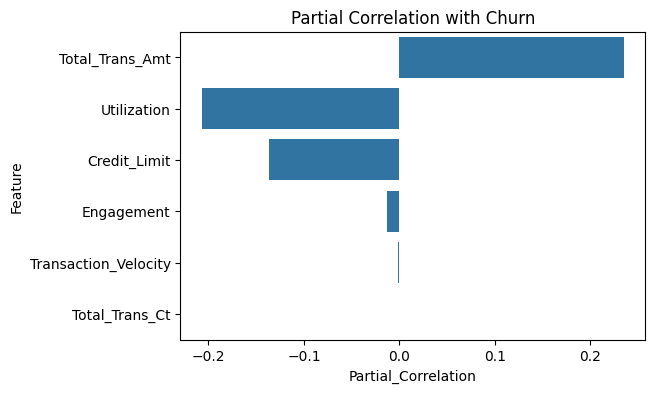

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(x="Partial_Correlation", y="Feature", data=pcorr_df)
plt.title("Partial Correlation with Churn")
plt.show()

# INTERACTION ANALYSIS

**Scatter Plot**

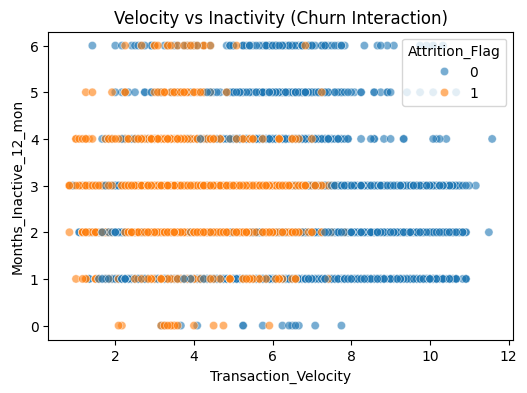

In [18]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Transaction_Velocity",
    y="Months_Inactive_12_mon",
    hue="Attrition_Flag",
    data=df,
    alpha=0.6
)

plt.title("Velocity vs Inactivity (Churn Interaction)")
plt.show()

**RISK HEATMAP**

In [22]:
df["Velocity_Bin"] = pd.qcut(df["Transaction_Velocity"], 5, duplicates="drop")
df["Inactivity_Bin"] = pd.qcut(df["Months_Inactive_12_mon"], 5, duplicates="drop")

In [ ]:
pivot = df.pivot_table(
    values="Attrition_Flag",
    index="Velocity_Bin",
    columns="Inactivity_Bin",
    aggfunc="mean",
    observed=False
    '''observed=False → show ALL bins (even if empty)
        observed=True  → show only bins present in data'''
)

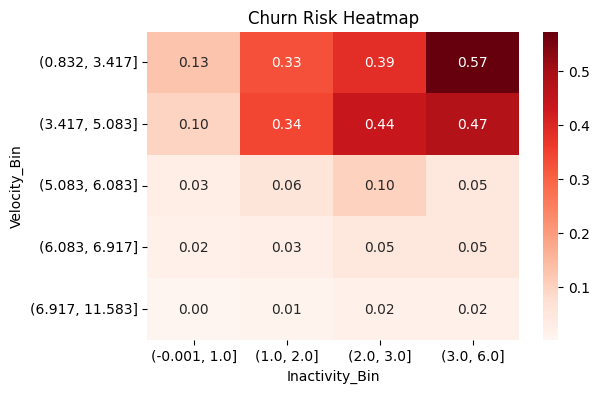

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Churn Risk Heatmap")
plt.show()

**CLUSTERING**

In [20]:
from sklearn.cluster import KMeans

features = df[[
    "Transaction_Velocity",
    "Engagement",
    "Utilization"
]]

scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled)

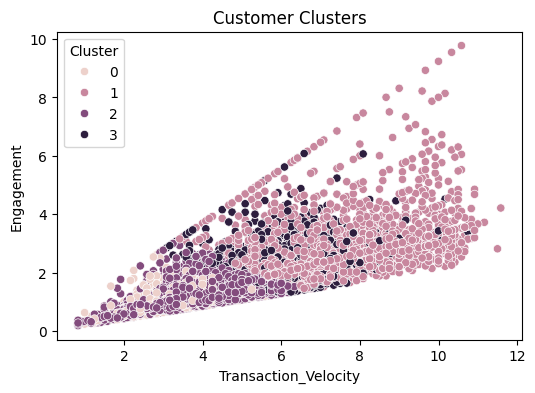

In [21]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Transaction_Velocity",
    y="Engagement",
    hue="Cluster",
    data=df
)

plt.title("Customer Clusters")
plt.show()

# Key Multivariate Insights

1. Churn is driven by interaction of features, not individual variables.

2. Low Transaction Velocity combined with high inactivity forms a high-risk churn zone.

3. Engagement acts as a stabilizing factor reducing churn probability.

4. Partial correlation confirms that behavioral features have independent influence on churn.

5. Cluster analysis reveals distinct customer personas beyond traditional segmentation.

Conclusion:
Customer churn is a multi-dimensional behavioral phenomenon requiring combined feature analysis.